# Phase 0 — Data acquisition

**Hard rules enforced here**: no accession is assumed; every accession's metadata is fetched from GEO / CELLxGENE Discover and
printed before use. Downloads are cached in `data/raw/` and never repeated once complete.

Outputs: `results/phase0_*.txt`, `results/tables/phase0_*.csv`, `results/figures/phase0_*.png`.

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, os.path.join(ROOT, "src"))
os.environ["PYTHONUTF8"] = "1"
from config import *
import subprocess
def sh(*args):
    """run a src/ script in a subprocess and embed its stdout in the notebook (child stdout bypasses the kernel otherwise)"""
    r = subprocess.run([sys.executable, *args], capture_output=True, text=True, encoding="utf-8", errors="replace")
    print(r.stdout)
    if r.returncode:
        print(r.stderr); raise RuntimeError(f"{args[0]} exited with {r.returncode}")
print("ROOT:", ROOT, "| SEED:", SEED)

ROOT: <repo> | SEED: 20260914


## 0.1 Confirmed accession: GSE216481 (Joung et al. 2023, TF Atlas)
GSE216481 is a **SuperSeries**; the ~670k-cell hESC TF-overexpression atlas is SubSeries **GSE217460** (`SHAREseq_210322_TFAtlas`).
We fetch metadata for the SuperSeries and all SubSeries, then download only the processed raw-count h5ad of GSE217460.
This dataset is **not analysed** in Phases 0–1 (reserved for Phase 2).

In [2]:
from geo_meta import summarize
meta = summarize("GSE216481")
import requests
t = requests.get("https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE216481&targ=self&form=text&view=full", timeout=60).text
subs = [l.split(": ")[-1] for l in t.splitlines() if l.startswith("!Series_relation = SuperSeries of")]
print("SubSeries:", subs)
_ = summarize("GSE217460")

ACCESSION: GSE216481
Title:       A Transcription Factor Atlas of Directed Differentiation
Organism:    Escherichia coli; Homo sapiens; Lentivirus
Type:        Expression profiling by high throughput sequencing; Genome binding/occupancy profiling by high throughput sequencing; Other
Platforms:   GPL15520; GPL18573; GPL20795; GPL21697; GPL24676; GPL28126; GPL32884
Status:      Public on Jan 05 2023
Submission:  Oct 24 2022
PubMed:      36608654
N samples:   281
Contributors:  ...
Summary:     This SuperSeries is composed of the SubSeries listed below.
Design:      Refer to individual Series
Supplementary files:
    ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE216nnn/GSE216481/suppl/GSE216481_RAW.tar


SubSeries: ['GSE216457', 'GSE216463', 'GSE216477', 'GSE216479', 'GSE216595', 'GSE216601', 'GSE216602', 'GSE217066', 'GSE217215', 'GSE217460', 'GSE218506', 'GSE218562', 'GSE218789', 'GSE219000', 'GSE219058']


ACCESSION: GSE217460
Title:       A Transcription Factor Atlas of Directed Differentiation [SHAREseq_210322_TFAtlas]
Organism:    Homo sapiens
Type:        Expression profiling by high throughput sequencing; Other
Platforms:   GPL24676
Status:      Public on Jan 05 2023
Submission:  Nov 07 2022
PubMed:      36608654
N samples:   48
Contributors: Julia,,Joung, Feng,,Zhang ...
Summary:     SHARE-seq single-cell RNA-seq data profiling hESCs overexpressing transcription factors
Design:      hESCs were transduced with a library of 3,550 transcription factor ORFs and cultured for 7 days before single-cell RNA-seq
Supplementary files:
    ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE217nnn/GSE217460/suppl/GSE217460_210322_TFAtlas_S01-S04.csv.gz
    ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE217nnn/GSE217460/suppl/GSE217460_210322_TFAtlas_differentiated.h5ad.gz
    ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE217nnn/GSE217460/suppl/GSE217460_210322_TFAtlas_differentiated_raw.h5ad.gz
    ftp://ftp.ncbi.n

In [3]:
# download (cached). The full raw h5ad is 4.69 GB gz; NCBI throttles per connection, so a segmented downloader is used.
sh("src/download.py", TF_ATLAS["small_url"], "--out", str(TF_ATLAS["local_dir"]))
sh("src/download_parallel.py", TF_ATLAS["raw_url"], "--out", str(TF_ATLAS["local_dir"]), "--n", "24")

[cached] <repo>\data\raw\GSE217460\GSE217460_210322_TFAtlas_differentiated_raw.h5ad.gz (0.13 GB) — complete, skipping



[cached] <repo>\data\raw\GSE217460\GSE217460_210322_TFAtlas_raw.h5ad.gz complete (4.69 GB); skipping



In [4]:
# verify the small companion file loads (backed mode) — X is stored DENSE float32 in these files
sh("src/verify_h5ad.py", str(TF_ATLAS["local_dir"] / "GSE217460_210322_TFAtlas_differentiated_raw.h5ad.gz"))

[cached] <repo>\data\raw\GSE217460\GSE217460_210322_TFAtlas_differentiated_raw.h5ad already decompressed
FILE: <repo>\data\raw\GSE217460\GSE217460_210322_TFAtlas_differentiated_raw.h5ad (4.33 GB on disk)
top-level keys: ['X', 'obs', 'var']
X: dense dataset (28825, 37528) float32
shape (cells, genes): (28825, 37528)
obs columns: ['TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'batchTF', 'score', 'temp', 'dpt_pseudotime', 'm3_pseudotime', 'difflouvain']
var columns: []
uns keys: []
obsm keys: []
obs head(3):
               R1.11,R2.75,R3.53,P1.54-0-1-0 R1.57,R2.65,R3.85,P1.62-1-1-0 R1.36,R2.43,R3.03,P1.07-2-1-0
TF                            TFORF3021-DLX4                TFORF3021-DLX4                TFORF3021-DLX4
batch                                      0                             0                             0
louvain                                    8                             7                             7
n_counts                              5272.0      

In [5]:
# verify the full raw file. Its X is DENSE float32: 1,145,823 cells x 37,528 genes = 172 GB decompressed (HDF5 superblock EOF
# address read from the gzip stream), which does not fit on disk. It is therefore converted in a single pass directly from the gzip
# stream into a sparse CSR h5ad (src/stream_convert_tf_atlas.py; ~11 min, <1 GB RAM). Prints shape and obs columns.
sh("src/stream_convert_tf_atlas.py")

[cached] <repo>\data\processed\GSE217460_TFAtlas_raw_sparse.h5ad
GSE216481 / GSE217460 TF Atlas raw counts (sparse-converted): shape (cells, genes) = (1145823, 37528)
obs columns: ['n_genes', 'percent_mito', 'n_counts', 'batch', 'TF']
var columns: ['n_cells-0-0', 'n_cells-0-1-0', 'n_cells-1-1-0', 'n_cells-2-1-0', 'n_cells-3-1-0', 'n_cells-0-2-0', 'n_cells-1-2-0', 'n_cells-2-2-0', 'n_cells-3-2-0', 'n_cells-0-3-0', 'n_cells-1-3-0', 'n_cells-2-3-0', 'n_cells-3-3-0', 'n_cells-0-4-0', 'n_cells-1-4-0', 'n_cells-2-4-0', 'n_cells-3-4-0', 'n_cells-0-1', 'n_cells-1-1', 'n_cells-2-1', 'n_cells-3-1']  (var index = gene symbols, e.g. ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', 'A2M-AS1'])
n distinct TF labels: 3,369
n batches: 2
             R1.01,R2.01,R3.01,P1.22-0-0 R1.01,R2.01,R3.02,P1.22-0-0 R1.01,R2.01,R3.05,P1.38-0-0
n_genes                             1642                        1892                        2159
percent_mito                     0.03065                    0.023033                    

## 0.2 Search for human single-cell aging atlases
Criteria: per-donor chronological age, ≥10 donors, age span ≥40 y (ideally 20–80), ≥3 cell types, scRNA-seq, PBMC/immune preferred.
Two independent sources are queried and everything they return is recorded:
1. **CELLxGENE Discover** curation API (structured donor / development-stage metadata for 2,226 datasets).
2. **NCBI GEO** (`gds` esearch) with aging + single-cell + PBMC terms.

In [6]:
from search_cxg import main as cxg_search
cand = cxg_search()

Querying CELLxGENE Discover /datasets ...


  2226 datasets total


  1621 human datasets



=== CELLxGENE candidates meeting: >=10 donors, numeric age span >=40y, >=3 cell types, scRNA-seq ===
n = 236
                          dataset_id                                                                                                                                                                                         title  cell_count  n_donors  n_cell_types   age_min  age_max  n_stages_numeric_years                                                                                                                                                                                                  tissues                                                                                                                 diseases  immune_like
3faad104-2ab8-4434-816d-474d8d2641db                                                                                                  Single-cell eQTL mapping identifies cell type specific genetic control of autoimmune disease     1248980       981 

In [7]:
sh("src/search_geo.py")

QUERY: (aging[Title] OR ageing[Title] OR "age-related"[Title] OR "healthy aging"[All Fields]) AND ("single-cell"[All Fields] OR "single cell"[All Fields] OR scRNA-seq[All Fields]) AND (PBMC[All Fields] OR "peripheral blood"[All Fields] OR immune[All Fields]) AND "Homo sapiens"[Organism] AND gse[Entry Type]
  GEO returned 34 records (showing up to 34)
  GSE343903   n_samples=    6  2026/08/20  Expression profiling by high throughput  | Single-Cell Analysis of the Aging Human Periovulatory Follicle Reveals Granulosa Cell Dysfunction and Immune D
  GSE338484   n_samples=   29  2026/07/13  Genome binding/occupancy profiling by hi | Somatic mutations reveal the ontogeny of microglia in human aging [snATAC-seq]
  GSE299953   n_samples=   28  2026/06/16  Expression profiling by high throughput  | Single-cell omics analysis of age-related immune signatures induced by Omicron sublineage breakthrough infecti
  GSE329693   n_samples=   36  2026/06/15  Expression profiling by high throughput  | Mi

In [8]:
# top immune candidates with collection DOI and file size
import pandas as pd, requests
c = pd.read_csv(TAB / "phase0_cxg_candidates.csv")
ids = ["3faad104-2ab8-4434-816d-474d8d2641db","c838aec3-03ef-4398-b882-0e3912abfff0","ff4235bb-1cdf-4dcf-a13a-dc4f32244400",
       "ca7d95ac-53aa-4a94-8c76-300c608ce6a0","789ad837-9bf5-436c-9b60-9f1153546e4c","d86edd6a-4b5d-437a-ad80-1fd976a5e23a",
       "1b350d0a-4535-4879-beb6-1142f3f94947","53d208b0-2cfd-4366-9866-c3c6114081bc"]
for _, r in c[c.dataset_id.isin(ids)].iterrows():
    col = requests.get(f"https://api.cellxgene.cziscience.com/curation/v1/collections/{r.collection_id}", timeout=60).json()
    print(f"{r.dataset_id} | {col.get('name')[:70]} | DOI {col.get('doi')}\n   cells={r.cell_count:,} donors={r.n_donors} cell_types={r.n_cell_types} "
          f"age={r.age_min:.0f}-{r.age_max:.0f} ({r.n_stages_numeric_years} distinct years) | {r.assays} | {r.tissues[:40]} | {r.diseases[:50]} | h5ad {(r.h5ad_bytes or 0)/1e9:.1f} GB")

3faad104-2ab8-4434-816d-474d8d2641db | Single-cell eQTL mapping identifies cell type specific genetic control | DOI 10.1126/science.abf3041
   cells=1,248,980 donors=981 cell_types=29 age=19-97 (78 distinct years) | 10x 3' v2 | blood | normal | h5ad 4.4 GB


c838aec3-03ef-4398-b882-0e3912abfff0 | Asian Immune Diversity Atlas (AIDA) | DOI 10.1016/j.cell.2025.02.017
   cells=1,265,624 donors=625 cell_types=32 age=19-77 (55 distinct years) | 10x 5' v2 | blood | normal | h5ad 14.2 GB


ff4235bb-1cdf-4dcf-a13a-dc4f32244400 | Immunobiology of Aging Cohort PBMC Profiling | DOI 10.1038/s41586-025-09686-5
   cells=3,758,514 donors=234 cell_types=37 age=40-89 (51 distinct years) | 10x gene expression flex | blood | cytomegalovirus infection; normal | h5ad 40.1 GB


ca7d95ac-53aa-4a94-8c76-300c608ce6a0 | Ancestral and environmental diversity shape the immune landscape in In | DOI 10.64898/2026.02.15.704933
   cells=462,034 donors=199 cell_types=13 age=18-60 (41 distinct years) | 10x 5' v2 | blood | normal | h5ad 3.9 GB


789ad837-9bf5-436c-9b60-9f1153546e4c | Progression to rheumatoid arthritis in at-risk individuals is defined  | DOI 10.1126/scitranslmed.adt7214
   cells=2,029,864 donors=89 cell_types=38 age=21-78 (50 distinct years) | 10x 3' v3 | blood | cytomegalovirus infection; cytomegalovirus infecti | h5ad 18.1 GB


d86edd6a-4b5d-437a-ad80-1fd976a5e23a | Automatic cell-type harmonization and integration across Human Cell At | DOI 10.1016/j.cell.2023.11.026
   cells=335,916 donors=65 cell_types=24 age=21-73 (32 distinct years) | 10x 3' v2; 10x 3' v3; 10x 5' v1; 10x 5' v2 | blood | normal | h5ad 2.4 GB


1b350d0a-4535-4879-beb6-1142f3f94947 | Multimodal profiling reveals tissue-directed signatures of human immun | DOI 10.1038/s41590-025-02241-4
   cells=1,281,499 donors=24 cell_types=31 age=20-75 (12 distinct years) | 10x 3' v3; 10x 5' v2 | blood; bone marrow; colonic epithelium;  | normal | h5ad 12.7 GB


53d208b0-2cfd-4366-9866-c3c6114081bc | Tabula Sapiens | DOI 10.1126/science.abl4896
   cells=1,136,218 donors=24 cell_types=180 age=22-74 (19 distinct years) | 10x 3' v3; 10x 5' v2; Smart-seq2; Smart-seq3 | abdominal aorta; adipose tissue; anterio | normal | h5ad 45.0 GB


### Decision
| role | dataset | why |
|---|---|---|
| **Primary** | **OneK1K** (Yazar et al. 2022, *Science*; GEO GSE196830/GSE196735; CELLxGENE `3faad104…`) | 981 healthy donors, ages 19–97 (78 distinct years → continuous), 29 cell types, 1.25 M PBMCs, 10x 3' v2, 4.4 GB |
| **Replication (held out, untouched in Phase 1)** | **AIDA Phase 1 v2** (*Cell* 2025; CELLxGENE `c838aec3…`) | 625 healthy donors, 19–77, 32 cell types, 10x 5' v2, independent cohort/ancestry/chemistry |

Also seen but not chosen: Immunobiology of Aging Cohort (234 donors, 40–89, 40 GB, CMV status mixed), Indonesia PBMC (199 donors, 18–60 — span 42 y borderline),
Tabula Sapiens (24 donors), Immune-aging project (24 donors), GEO GSE157007 (Luo et al.: 3 young / 6 old / 5 frail → **binned**, would fire STOP 0).

In [9]:
sh("src/download.py", PRIMARY["h5ad_url"], "--out", str(PRIMARY["local"].parent))
sh("src/verify_h5ad.py", str(PRIMARY["local"]))

[cached] <repo>\data\raw\onek1k\1e44db10-b572-46cc-adae-dcc7acd44ca6.h5ad (4.43 GB) — complete, skipping



FILE: <repo>\data\raw\onek1k\1e44db10-b572-46cc-adae-dcc7acd44ca6.h5ad (4.43 GB on disk)
top-level keys: ['X', 'layers', 'obs', 'obsm', 'obsp', 'uns', 'var', 'varm', 'varp']
X: sparse group, encoding: {'encoding-type': 'csr_matrix', 'encoding-version': '0.1.0', 'shape': array([1248980,   35528])} data dtype: float32 nnz: 1183532685
layers: []
shape (cells, genes): (1248980, 35528)
obs columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'donor_id', 'pool_number', 'predicted.celltype.l2', 'predicted.celltype.l2.score', 'age', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']
var columns: ['vst.mean', 'vst.variance', 'vst.variance.expected

In [10]:
from profile_dataset import main as profile
donors = profile(str(PRIMARY["local"]), "onek1k")

=== onek1k: 1,248,980 cells x 35,528 genes ===
X sample: dtype=float32 min=1.0 max=7060.0 integer-fraction=1.00000
donors: 981
age: min=19 max=97 mean=63.9 median=67 distinct values=78  -> CONTINUOUS (per-year)
age decade distribution (n donors):
age
(10, 20]       9
(20, 30]      43
(30, 40]      64
(40, 50]      75
(50, 60]     136
(60, 70]     256
(70, 80]     269
(80, 90]     118
(90, 100]     11
sex: {'female': 565, 'male': 416}
cells per donor: median=1246 min=333 max=3511
pools: 75

cell types [cell_type]: 29
cell_type
central memory CD4-positive, alpha-beta T cell           289000
naive thymus-derived CD4-positive, alpha-beta T cell     259012
natural killer cell                                      164933
effector memory CD8-positive, alpha-beta T cell          161051
naive B cell                                              65702
naive thymus-derived CD8-positive, alpha-beta T cell      52538
CD14-positive monocyte                                    36130
effector memory CD4-


sex-age check: male mean age 64.2 (n=416), female 63.7 (n=565); Welch t p=0.586

STOP CONDITION 0: NOT fired (>=10 donors, continuous age, span>=40y, >=3 cell types)


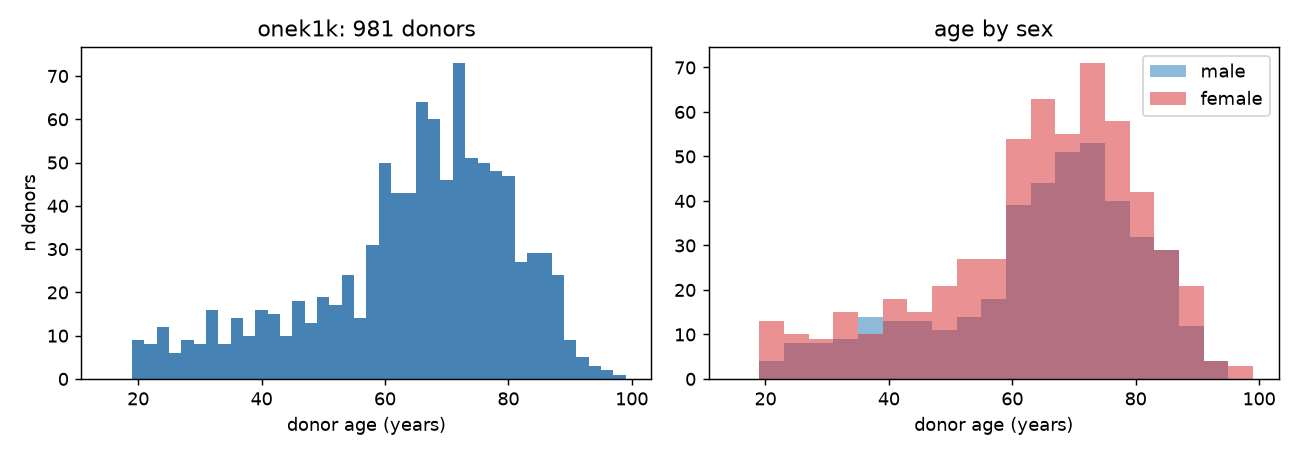

In [11]:
from IPython.display import Image, display
display(Image(str(FIG / "phase0_onek1k_donor_age_distribution.png")))

In [12]:
# replication set: download only (NOT opened in Phase 1)
sh("src/download.py", REPLICATION["h5ad_url"], "--out", str(REPLICATION["local"].parent))

[cached] <repo>\data\raw\aida\f89a12c2-7a3b-415b-ab87-bbc550fe17f4.h5ad (14.24 GB) — complete, skipping

